# 📊 Customer Churn Prediction - Exploratory Data Analysis

## 🎯 Objective
Analyze customer behavior and identify key factors driving churn in a telecom company.

## 📁 Dataset
Telco Customer Churn Dataset

## 🔍 Key Questions
- What percentage of customers churn?
- Which features influence churn the most?
- How do tenure and charges affect churn?
- Which services reduce churn?

## 🧠 Business Goal
Reduce churn by identifying high-risk customers and enabling targeted retention strategies.

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# display settings
pd.set_option("display.max_columns", None)

## 📥 Load Dataset

In [17]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🧾 Basic Dataset Overview

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## ❗ Missing Values Analysis

In [20]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].isnull().sum()

np.int64(11)

## 🎯 Target Variable Analysis (Churn)

In [22]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

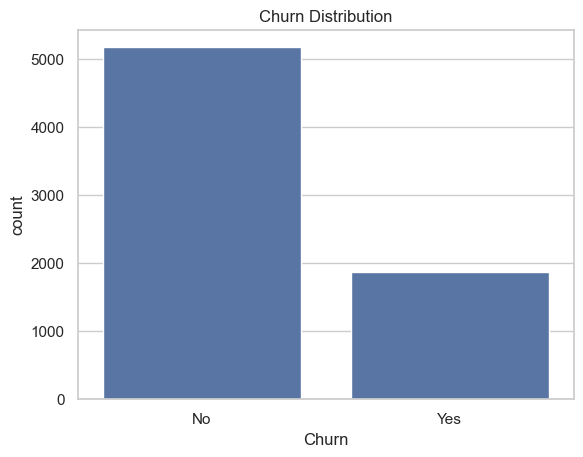

In [23]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

## 📊 Categorical Feature Analysis

In [24]:
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

C:\Users\HP\AppData\Local\Temp\ipykernel_70480\3430876840.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

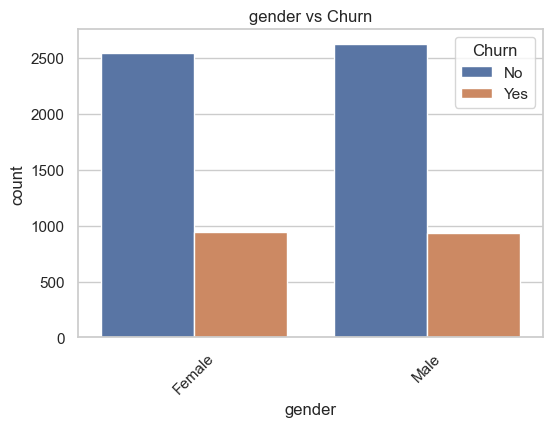

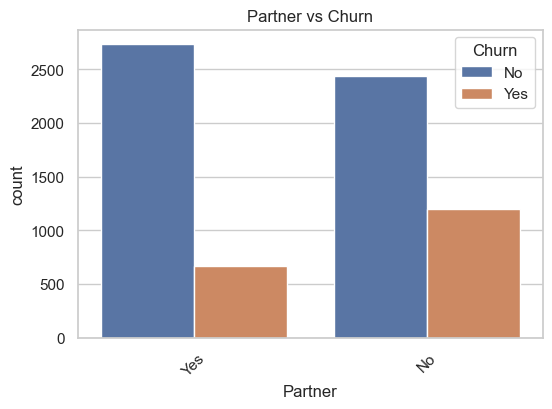

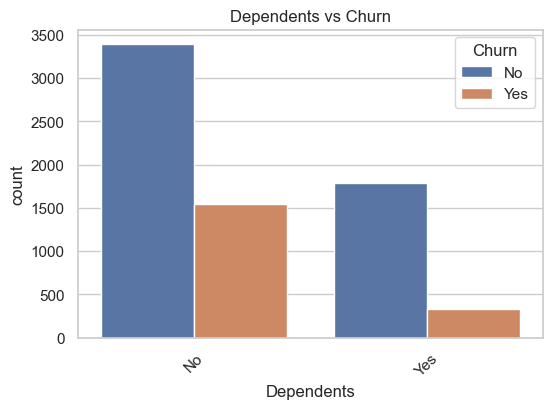

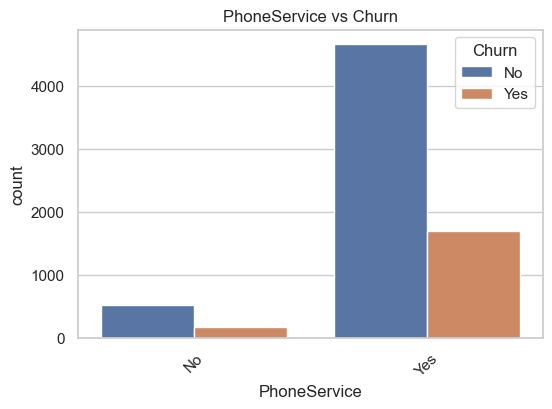

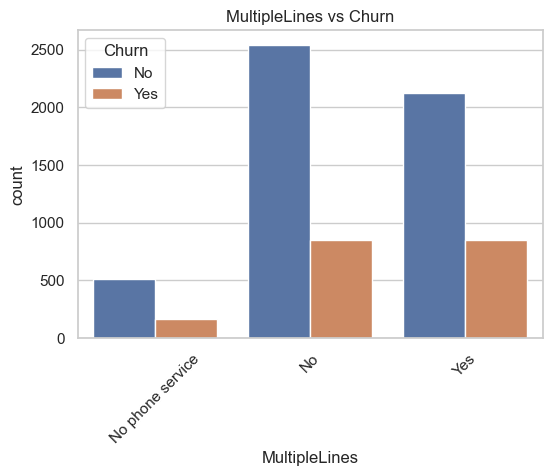

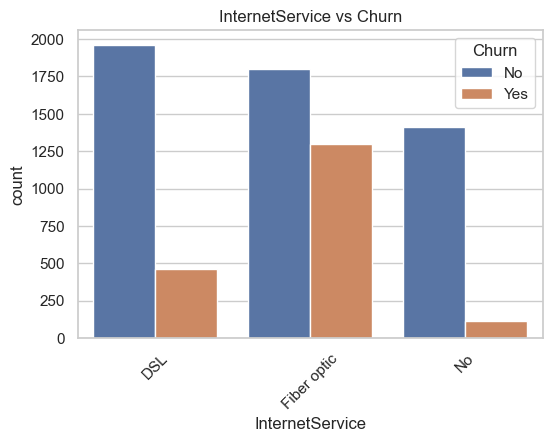

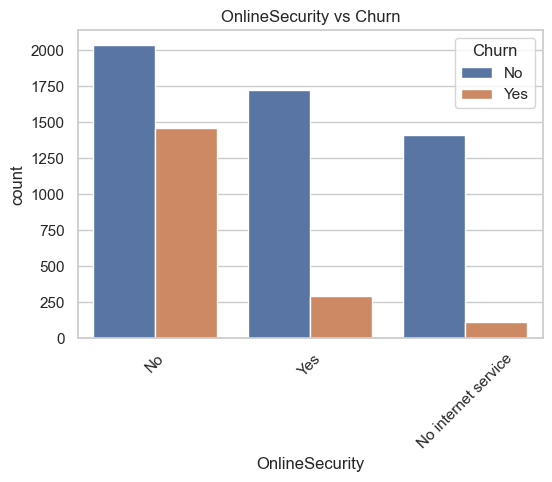

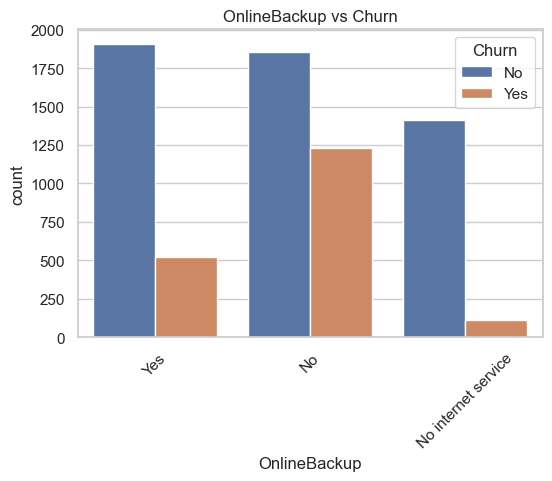

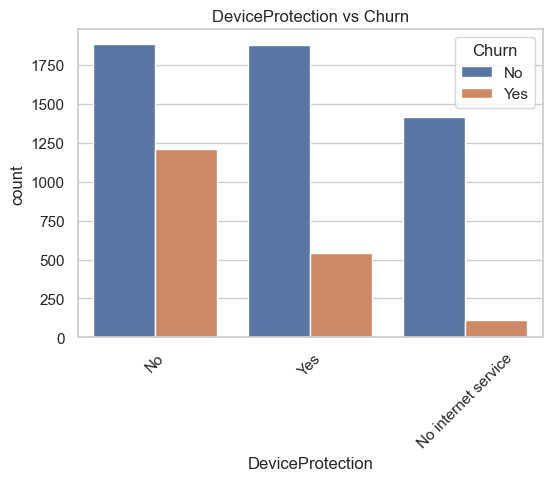

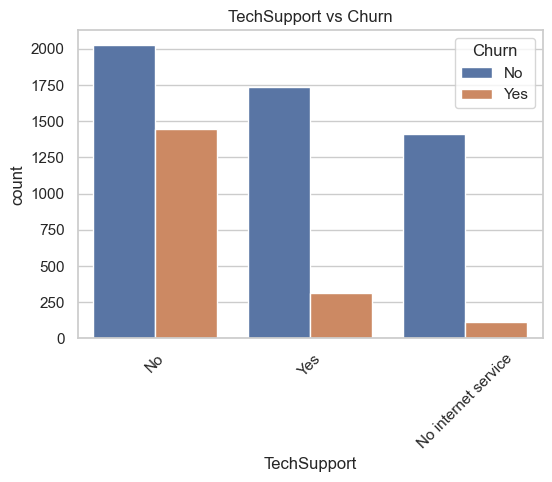

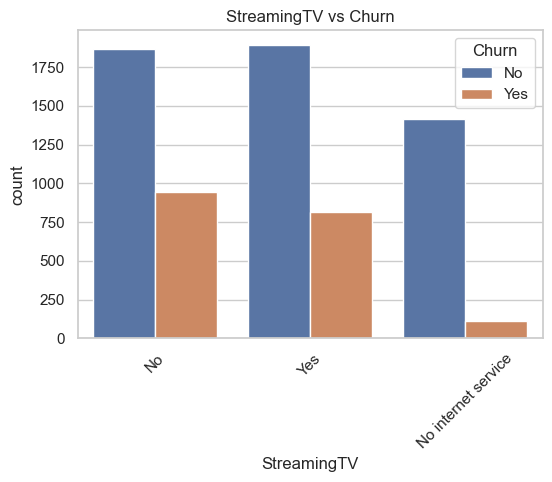

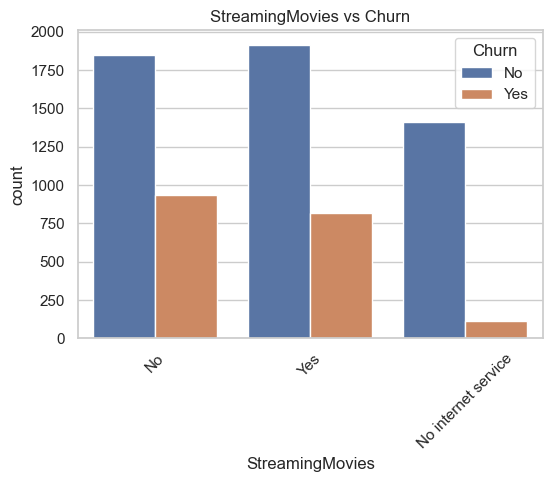

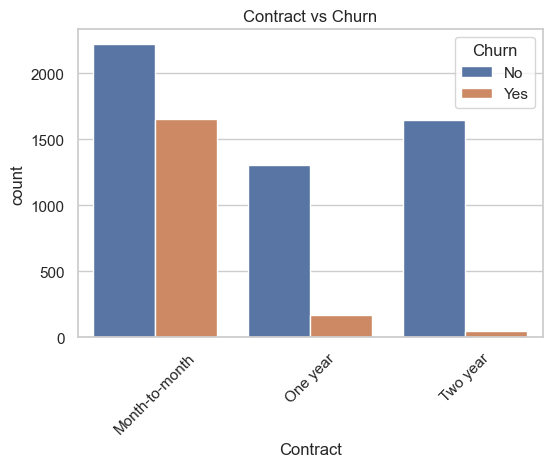

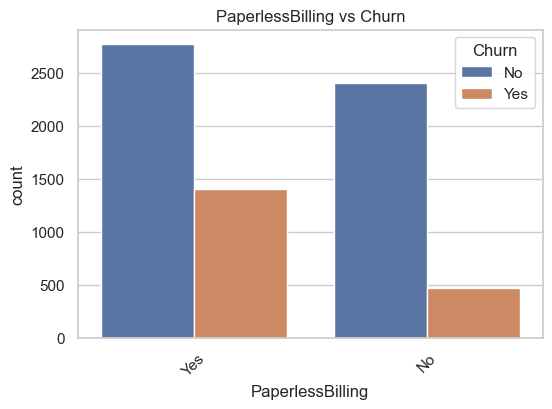

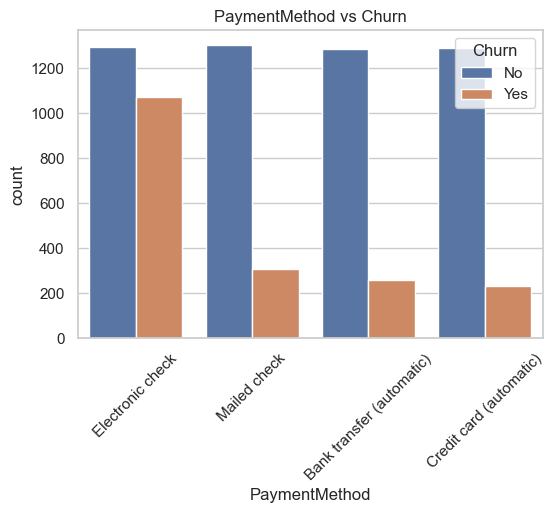

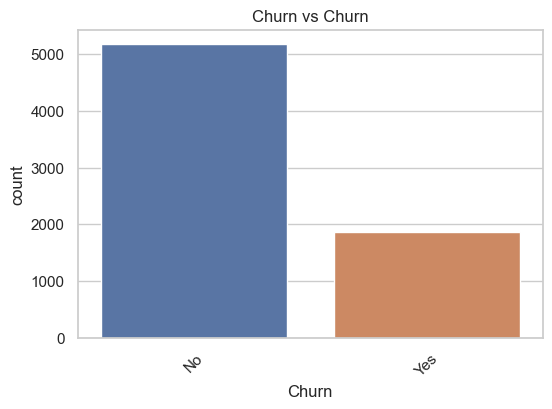

In [25]:
for col in categorical_cols:
    if col != "customerID":
        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=col, hue="Churn")
        plt.title(f"{col} vs Churn")
        plt.xticks(rotation=45)
        plt.show()

## 📈 Numerical Feature Analysis

In [26]:
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
numerical_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

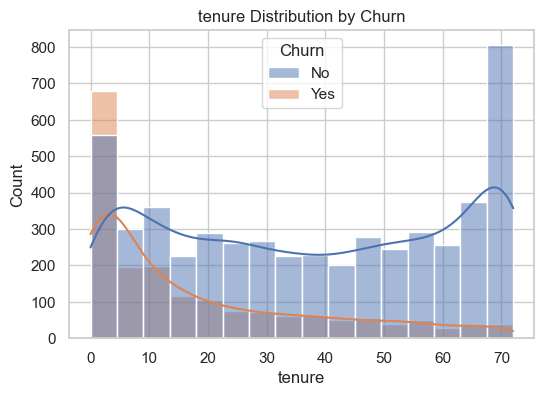

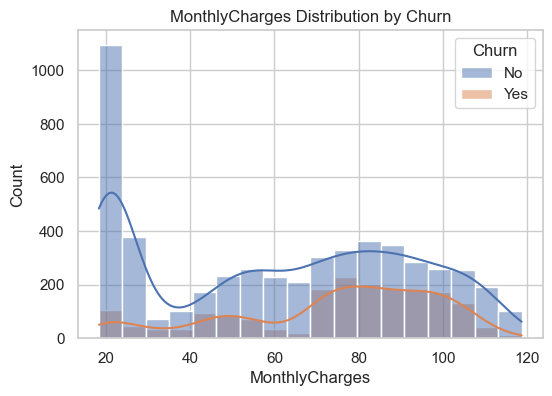

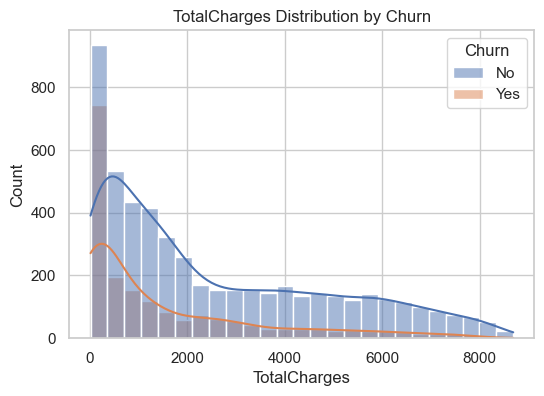

In [27]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="Churn", kde=True)
    plt.title(f"{col} Distribution by Churn")
    plt.show()

## 🔗 Correlation Analysis

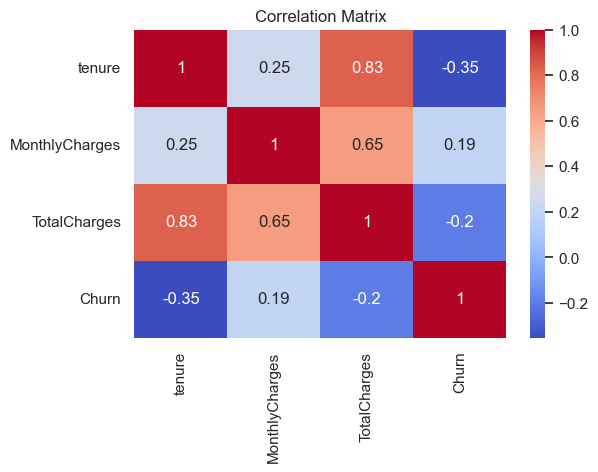

In [28]:
# Convert target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

corr = df[numerical_cols + ["Churn"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 💡 Key Insights

### 🔥 High Impact Features
- Tenure → shorter tenure = higher churn
- MonthlyCharges → higher charges increase churn
- Contract Type → month-to-month customers churn more

### 📉 Service Impact
- Lack of TechSupport increases churn
- No OnlineSecurity → higher churn

### 💰 Revenue Insights
- High-paying customers are at risk
- Long-term contracts reduce churn significantly

### ⚠️ Business Risk
- New customers are most vulnerable
- High-value churn = revenue loss

---
